In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import speckleret

import torch
import speckleret as spr
import speckleret.torch as tspr

import scipy.io as sio
from types import SimpleNamespace

In [2]:
fiber = SimpleNamespace(sio.loadmat('../../imports/step_index_modes.mat', squeeze_me=True, struct_as_record=True))

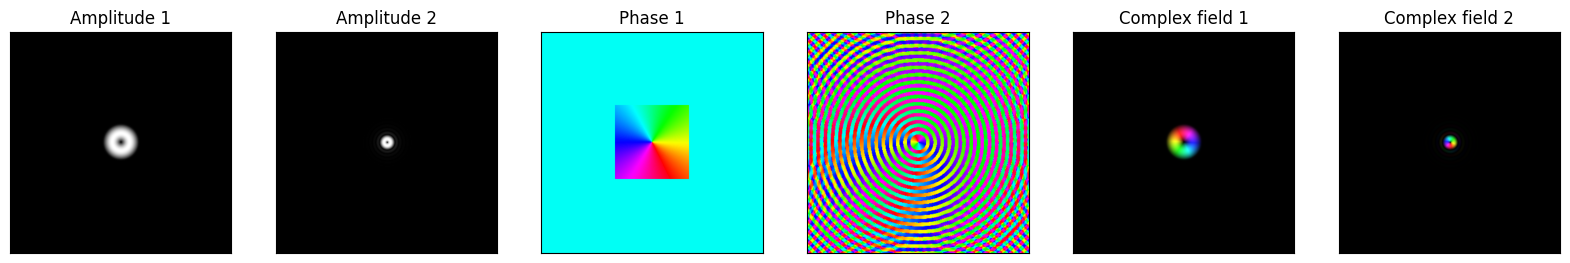

In [106]:
mode_index = 1

field = fiber.modes[..., 0, mode_index] + 1j * fiber.modes[..., 1, mode_index]
field = speckleret.transforms.pad_img(field, pad=2)
ft = speckleret.transforms.fourier_transform(field, pad=None)



field = torch.from_numpy(field).to(torch.cfloat)
ft = torch.from_numpy(ft).to(torch.cfloat)

## Apply saturation
trsh = 0.8
ft_abs = torch.abs(ft)
# ft_abs[ft_abs >= trsh * ft_abs.max()] = trsh * ft_abs.max()
# ft = ft_abs / ft_abs.max() * torch.exp(1j * ft.angle())
ft = torch.nn.functional.tanh(ft_abs / ft_abs.max()) * torch.exp(1j * ft.angle())

_ = speckleret.plots.compare_complex_fields(field.numpy(), ft.numpy(), remove_ticks=True, figsize=(20, 8))

In [107]:
ft.abs().square().max()

tensor(0.5800)

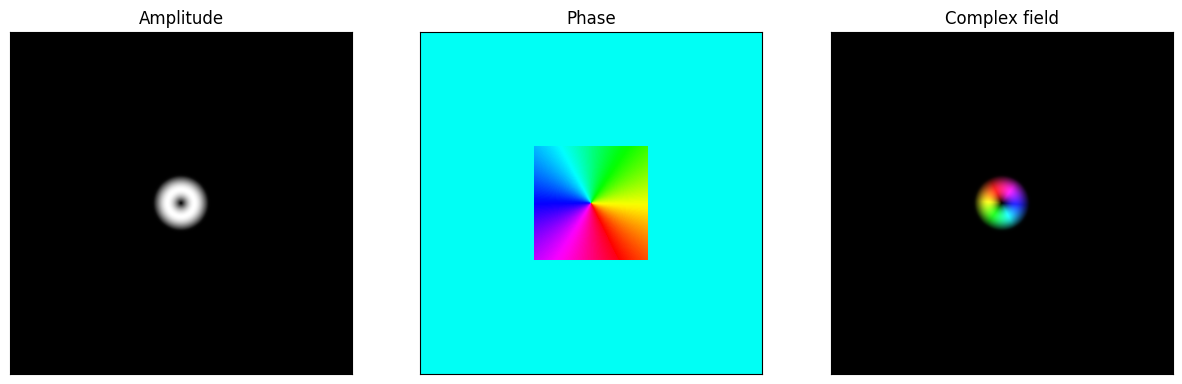

In [108]:
tfield = field.unsqueeze(0).unsqueeze(0)
tft = ft.unsqueeze(0).unsqueeze(0)

support = tspr.supports.threshold_support(tfield, threshold=0.00)
supported_field = field * support

_ = speckleret.plots.complex_imshow(torch.squeeze(supported_field).numpy(), remove_ticks=True)

In [109]:
def merge_dicts(dict_list) -> dict:
    merged_dict = {}
    for d in dict_list:
        for key, array in d.items():
            if key in merged_dict:
                merged_dict[key] = torch.concatenate((merged_dict[key], array))
            else:
                merged_dict[key] = array  # Initialize with first occurrence
    return merged_dict

Total time: 1.1252 seconds


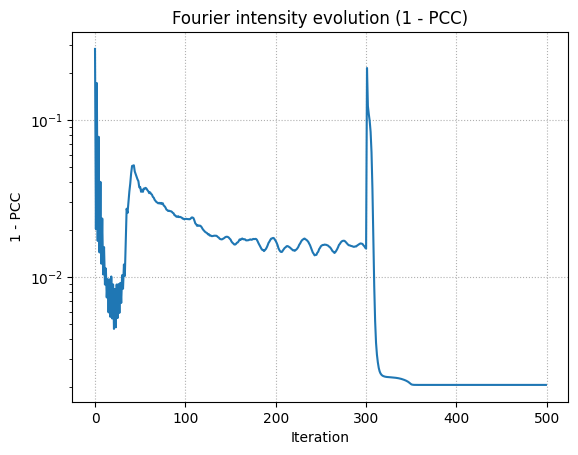

In [110]:
import torch.optim as optim


device = 'cuda'

tfield = tfield.to(device)
tft = tft.to(device)
support = support.to(device)


if device.startswith("cuda"):
    torch.cuda.synchronize()
    start_event = torch.cuda.Event(enable_timing=True)
    end_event = torch.cuda.Event(enable_timing=True)
    start_event.record()

results = []

x, result = tspr.retrieval.run(
        magnitudes=(torch.abs(tfield), torch.abs(tft)),
        support=support,
        init=tspr.initializers.flat_phases(torch.abs(tfield)),
        # init=tspr.initializers.random_phases(torch.abs(tfield)),
        algorithm=tspr.retrieval.RAAR,
        algorithm_kwargs={'beta': 0.90},
        max_iter=300,
)
results.append(result)


x, result = tspr.retrieval.run(
        magnitudes=(torch.abs(tfield), torch.abs(tft)),
        support=support,
        init=x,
        algorithm=tspr.retrieval.ER,
        max_iter=200,
)
results.append(result)

end_event.record()
torch.cuda.synchronize()
elapsed_time_ms = start_event.elapsed_time(end_event)
print(f"Total time: {elapsed_time_ms/1000:.4f} seconds")



tspr.retrieval.report_convergence_results(merge_dicts(results), key='pearson_fourier')

x_hat = x
y_hat = tspr.transforms.fourier_transform(x_hat)

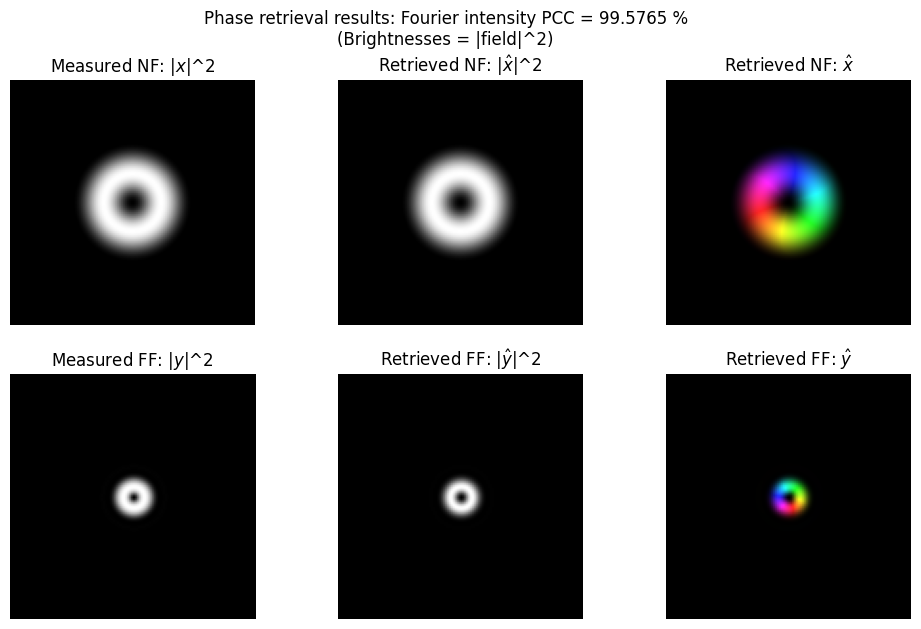

In [111]:
hfig = spr.retrievalmath.show_retrieved_fields(
    tfield.cpu().detach().squeeze().numpy(),
    tft.cpu().detach().squeeze().numpy(),
    x_hat.cpu().detach().squeeze().numpy(),
    y_hat.cpu().detach().squeeze().numpy(),
    power=2,
    window_crop=128,
    window_crop_ff=128,
)